# HaGRID 5-Class Object Detection with Ultralytics YOLOv11n

This notebook implements a complete object detection pipeline using **Ultralytics YOLOv11 Nano** (hardcoded).

## Features
- **YOLOv11 Nano model** (hardcoded, optimized for speed & mAP50)
- **Extended training** (80 epochs instead of 50 for better convergence)
- **Best-model selection** based on validation mAP50 per epoch
- **HaGRID format → YOLO format** annotation conversion
- **Multi-environment support** (Local, Kaggle, Google Colab)
- **Comprehensive evaluation** (mAP, precision, recall)
- **Live inference visualization**

## Target Classes
- `one`, `peace`, `three`, `four`, `fist`


In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

print('✓ OpenMP compatibility mode enabled')

✓ OpenMP compatibility mode enabled


In [2]:
import os
import sys
import importlib.util
from pathlib import Path

def get_environment() -> str:
    if os.getenv('KAGGLE_DATA_FOLDER') or os.path.exists('/kaggle/input'):
        return 'kaggle'
    if importlib.util.find_spec('google.colab') is not None:
        return 'colab'
    return 'local'

def find_kaggle_hagrid_root() -> Path:
    preferred = Path('/kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p')
    if preferred.exists():
        return preferred
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        for candidate in kaggle_input.rglob('*'):
            if candidate.is_dir() and (candidate / 'ann_train_val').exists() and (candidate / 'hagrid_30k').exists():
                return candidate
    return preferred

ENVIRONMENT = get_environment()
if ENVIRONMENT == 'kaggle':
    DATASET_ROOT = find_kaggle_hagrid_root()
    MODEL_DIR = Path('/kaggle/working/models')
    YOLO_DATASET_DIR = Path('/kaggle/working/yolo_hagrid_dataset')
elif ENVIRONMENT == 'colab':
    DATASET_ROOT = Path('/content/hagrid_dataset/hagrid-sample-30k-384p')
    MODEL_DIR = Path('/content/models')
    YOLO_DATASET_DIR = Path('/content/yolo_hagrid_dataset')
else:
    REPO_ROOT = Path('.').resolve()
    DATASET_ROOT = REPO_ROOT / 'data' / 'hagrid-sample-30k-384p-5class'
    MODEL_DIR = REPO_ROOT / 'models' / 'yolo'
    YOLO_DATASET_DIR = REPO_ROOT / 'models' / 'yolo' / 'yolo_hagrid_dataset'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
YOLO_DATASET_DIR.mkdir(parents=True, exist_ok=True)
print(f'Environment: {ENVIRONMENT}')
print(f'Dataset: {DATASET_ROOT}')
print(f'Models: {MODEL_DIR}')


Environment: kaggle
Dataset: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p
Models: /kaggle/working/models


In [3]:
import json, yaml, random, time, subprocess
import torch, numpy as np, pandas as pd, cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter

try:
    from ultralytics import YOLO
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'ultralytics'])
    from ultralytics import YOLO

SEED = 24520789
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Imports complete | Device: {device}')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Imports complete | Device: cuda


In [4]:
print(f'Environment: {ENVIRONMENT}')
print(f'Dataset exists: {DATASET_ROOT.exists()}')
if DATASET_ROOT.exists():
    ann_dir = DATASET_ROOT / 'ann_train_val'
    print(f'Annotations: {ann_dir.exists()}')
    if ann_dir.exists():
        jsons = list(ann_dir.glob('*.json'))
        print(f'JSON files: {len(jsons)}')

packages = ['torch', 'torchvision', 'PIL', 'pandas', 'cv2', 'numpy', 'ultralytics']
for pkg in packages:
    try:
        __import__(pkg)
        print(f'✓ {pkg}')
    except:
        print(f'✗ {pkg} MISSING')


Environment: kaggle
Dataset exists: True
Annotations: True
JSON files: 18
✓ torch
✓ torchvision
✓ PIL
✓ pandas
✓ cv2
✓ numpy
✓ ultralytics


In [5]:
KEEP_CLASSES = ['one', 'peace', 'three', 'four', 'fist']
TARGET_CLASSES = KEEP_CLASSES
CLASS_TO_ID = {c: i for i, c in enumerate(TARGET_CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def build_filename_index(root: Path):
    idx = {}
    for p in root.rglob('*'):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            idx[p.name] = p
            idx[p.stem] = p
    return idx

def resolve_image_path(idx: dict, key: str):
    k = Path(key).stem
    return idx.get(k) or idx.get(Path(key).name)

def xywh_to_xyxy(box, w, h, normalized=True):
    x, y, bw, bh = box
    if normalized:
        x, y, bw, bh = x*w, y*h, bw*w, bh*h
    return [max(0, x), max(0, y), min(w-1, x+bw), min(h-1, y+bh)]

def xyxy_to_yolo_norm(x1, y1, x2, y2, w, h):
    cx, cy = (x1+x2)/(2*w), (y1+y2)/(2*h)
    bw, bh = (x2-x1)/w, (y2-y1)/h
    return [cx, cy, bw, bh]

print(f'Classes: {TARGET_CLASSES}')


Classes: ['one', 'peace', 'three', 'four', 'fist']


In [6]:
def parse_and_convert_to_yolo(dataset_root, target_classes, output_dir):
    ann_dir = dataset_root / 'ann_train_val'
    img_root = dataset_root / 'hagrid_30k'
    output_dir.mkdir(parents=True, exist_ok=True)
    (output_dir / 'images').mkdir(exist_ok=True)
    (output_dir / 'labels').mkdir(exist_ok=True)
    
    print(f'Converting HaGRID to YOLO format...')
    filename_index = build_filename_index(img_root)
    records = []
    
    for class_name in target_classes:
        json_path = ann_dir / f'{class_name}.json'
        if not json_path.exists():
            continue
        
        data = json.loads(json_path.read_text())
        for image_key, item in data.items():
            labels = item.get('labels') or []
            bboxes = item.get('bboxes') or []
            if not labels or not bboxes:
                continue
            
            img_path = resolve_image_path(filename_index, image_key)
            if not img_path:
                continue
            
            try:
                img = Image.open(img_path).convert('RGB')
                w, h = img.size
            except:
                continue
            
            label_lines = []
            for label, box in zip(labels, bboxes):
                if label not in target_classes or not isinstance(box, (list, tuple)) or len(box) < 4:
                    continue
                norm = max(box[:4]) <= 1.5
                x1, y1, x2, y2 = xywh_to_xyxy(box[:4], w, h, normalized=norm)
                cx, cy, bw, bh = xyxy_to_yolo_norm(x1, y1, x2, y2, w, h)
                class_id = CLASS_TO_ID[label]
                label_lines.append(f'{class_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}')
            
            if label_lines:
                output_img = output_dir / 'images' / img_path.name
                if not output_img.exists():
                    img.save(output_img)
                label_file = output_dir / 'labels' / (img_path.stem + '.txt')
                label_file.write_text('\n'.join(label_lines) + '\n')
                records.append({'image_path': str(output_img), 'label_path': str(label_file), 'image_name': img_path.name})
    
    print(f'✓ Converted {len(records)} samples')
    return records

records = parse_and_convert_to_yolo(DATASET_ROOT, TARGET_CLASSES, YOLO_DATASET_DIR)
img_counts = Counter(r['image_name'] for r in records)
records = [r for r in records if img_counts[r['image_name']] == 1]
if not records:
    raise RuntimeError(f'No YOLO samples were created from {DATASET_ROOT}. Check that the Kaggle dataset root is correct and contains ann_train_val/ and hagrid_30k/.')
print(f'After single-hand filter: {len(records)}')


Converting HaGRID to YOLO format...
✓ Converted 8837 samples
After single-hand filter: 8837


In [7]:
random.shuffle(records)
n = len(records)
n_train, n_val = int(0.7*n), int(0.15*n)

train_records = records[:n_train]
val_records = records[n_train:n_train+n_val]
test_records = records[n_train+n_val:]

print(f'Split: {len(train_records)} train, {len(val_records)} val, {len(test_records)} test')

yolo_root = YOLO_DATASET_DIR / 'yolo_splits'
yolo_root.mkdir(exist_ok=True)

for split_name, split_records in [('train', train_records), ('val', val_records), ('test', test_records)]:
    split_dir = yolo_root / split_name
    (split_dir / 'images').mkdir(parents=True, exist_ok=True)
    (split_dir / 'labels').mkdir(parents=True, exist_ok=True)
    for record in split_records:
        src_img, src_lbl = Path(record['image_path']), Path(record['label_path'])
        dst_img = split_dir / 'images' / src_img.name
        dst_lbl = split_dir / 'labels' / src_lbl.name
        if src_img.exists() and not dst_img.exists():
            import shutil
            shutil.copy2(src_img, dst_img)
        if src_lbl.exists() and not dst_lbl.exists():
            shutil.copy2(src_lbl, dst_lbl)

dataset_yaml = {
    'path': str(yolo_root),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': len(TARGET_CLASSES),
    'names': TARGET_CLASSES
}
yaml_path = yolo_root / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f)
print(f'✓ Dataset splits created at {yolo_root}')


Split: 6185 train, 1325 val, 1327 test
✓ Dataset splits created at /kaggle/working/yolo_hagrid_dataset/yolo_splits


In [8]:
print(f"\n{'='*70}")
print('LOADING YOLOv11n MODEL (HARDCODED)')
print(f"{'='*70}")

model_name = 'YOLOv11n'
model_file = 'yolo11n.pt'
print(f'Model: {model_name}')
print(f'File: {model_file}')
print(f'Note: YOLOv11n is hardcoded (no fallback to other models)')

try:
    yolo_model = YOLO(model_file)
    yolo_model.to(device)
    print(f'✓ {model_name} loaded successfully')
except Exception as e:
    print(f'✗ Failed to load {model_name}: {str(e)[:100]}')
    raise



LOADING YOLOv11n MODEL (HARDCODED)
Model: YOLOv11n
File: yolo11n.pt
Note: YOLOv11n is hardcoded (no fallback to other models)
✓ YOLOv11n loaded successfully


In [9]:
# Fine-tune YOLOv11n on the 5-class dataset
print(f"\n{'='*70}")
print("FINE-TUNING YOLOv11n ON HaGRID 5-CLASS DATASET")
print(f"{'='*70}")

# INCREASED EPOCHS FOR BETTER NANO CONVERGENCE
TRAIN_EPOCHS = 80
TRAIN_IMG_SIZE = 640
TRAIN_BATCH_SIZE = 16
TRAIN_LR = 1e-4
TRAIN_PATIENCE = 20  # Increased patience for longer training

MODEL_SAVE_PATH = MODEL_DIR / 'yolo11n_hagrid_best.pt'

print(f"Training Configuration:")
print(f"  Epochs: {TRAIN_EPOCHS} (INCREASED from 50 for nano convergence)")
print(f"  Image size: {TRAIN_IMG_SIZE}")
print(f"  Batch size: {TRAIN_BATCH_SIZE}")
print(f"  Learning rate: {TRAIN_LR}")
print(f"  Patience: {TRAIN_PATIENCE}")
print(f"  Best model tracking: ENABLED (validation accuracy)")

# Start training
print(f"\nStarting YOLOv11n training on {ENVIRONMENT}...")

if MODEL_SAVE_PATH.exists():
    print(f"✓ Model already exists at {MODEL_SAVE_PATH}, skipping training!")
    yolo_model = YOLO(str(MODEL_SAVE_PATH))
else:
    results = yolo_model.train(
        data=str(yaml_path),
        epochs=TRAIN_EPOCHS,
        imgsz=TRAIN_IMG_SIZE,
        batch=TRAIN_BATCH_SIZE,
        lr0=TRAIN_LR,
        patience=TRAIN_PATIENCE,
        device=0 if torch.cuda.is_available() else 'cpu',
        project=str(MODEL_DIR / 'yolo_runs'),
        name='hagrid_yolo11n',
        exist_ok=True,
        verbose=True,
        save=True,
        val=True,
        plots=True,
        mosaic=1.0,
        flipud=0.5,
        fliplr=0.5,
    )
    
    print(f"\n{'='*70}")
    print("TRAINING COMPLETE")
    print(f"{'='*70}")
    fitness_value = None
    if hasattr(results, 'box') and hasattr(results.box, 'fitness'):
        try:
            fitness_value = results.box.fitness()
        except TypeError:
            fitness_value = results.box.fitness
    elif hasattr(results, 'results_dict') and isinstance(getattr(results, 'results_dict'), dict):
        fitness_value = results.results_dict.get('fitness')
    
    if fitness_value is not None:
        print(f'Best fitness achieved: {float(fitness_value):.4f}')
    else:
        print('Best fitness achieved: unavailable in this Ultralytics version')
    
    # COPY BEST MODEL (selected by Ultralytics based on validation accuracy)
    trainer = getattr(yolo_model, 'trainer', None)
    save_dir = Path(trainer.save_dir) if trainer is not None and getattr(trainer, 'save_dir', None) else (MODEL_DIR / 'yolo_runs' / 'hagrid_yolo11n')
    best_model_path = save_dir / 'weights' / 'best.pt'
    if best_model_path.exists():
        import shutil
        shutil.copy2(best_model_path, MODEL_SAVE_PATH)
        print(f'✓ Best model saved to: {MODEL_SAVE_PATH}')
        print(f'  (Model selected based on best validation accuracy across {TRAIN_EPOCHS} epochs)')
    else:
        print('⚠ Note: Check training logs for best model path')



FINE-TUNING YOLOv11n ON HaGRID 5-CLASS DATASET
Training Configuration:
  Epochs: 80 (INCREASED from 50 for nano convergence)
  Image size: 640
  Batch size: 16
  Learning rate: 0.0001
  Patience: 20
  Best model tracking: ENABLED (validation accuracy)

Starting YOLOv11n training on kaggle...
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_hagrid_dataset/yolo_splits/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v

In [10]:
# Evaluate on validation and test sets
print(f"\n{'='*70}")
print("EVALUATION ON VALIDATION AND TEST SETS")
print(f"{'='*70}")

# Load the best trained model (with fallback to run artifacts)
candidate_model_paths = [MODEL_SAVE_PATH]
trainer = getattr(yolo_model, 'trainer', None)
save_dir = Path(trainer.save_dir) if trainer is not None and getattr(trainer, 'save_dir', None) else (MODEL_DIR / 'yolo_runs' / 'hagrid_yolo11n')
candidate_model_paths.extend([save_dir / 'weights' / 'best.pt', save_dir / 'weights' / 'last.pt'])
load_path = next((p for p in candidate_model_paths if Path(p).exists()), None)
if load_path is None:
    raise FileNotFoundError(f'No trained checkpoint found. Checked: {candidate_model_paths}')
trained_model = YOLO(load_path)
trained_model.to(device)
print(f"Model loaded from: {load_path}")

# Validate
print("\nRunning validation...")
val_results = trained_model.val(
    data=str(yaml_path),
    imgsz=TRAIN_IMG_SIZE,
    batch=TRAIN_BATCH_SIZE,
    device=0 if torch.cuda.is_available() else 'cpu',
    verbose=True,
)

print("\nValidation metrics:")
print(f"  mAP50: {val_results.box.map50:.4f}")
print(f"  mAP50-95: {val_results.box.map:.4f}")
print(f"  Precision: {val_results.box.mp:.4f}")
print(f"  Recall: {val_results.box.mr:.4f}")

# Test on test set
print("\nRunning inference on test set...")
test_images_dir = yolo_root / 'test' / 'images'
test_results = trained_model.predict(
    source=str(test_images_dir),
    conf=0.3,
    iou=0.45,
    imgsz=TRAIN_IMG_SIZE,
    device=0 if torch.cuda.is_available() else 'cpu',
    verbose=True,
)

print(f"\n✓ Test inference complete")
print(f"  Detections processed: {len(test_results)}")

# Compute metrics
metrics_summary = {
    'mAP50': float(val_results.box.map50),
    'mAP50-95': float(val_results.box.map),
    'Precision': float(val_results.box.mp),
    'Recall': float(val_results.box.mr),
    'Epochs_trained': TRAIN_EPOCHS,
    'Model': model_name,
    'Environment': ENVIRONMENT,
}

print("\nFinal Metrics Summary:")
for key, value in metrics_summary.items():
    print(f"  {key}: {value}")


EVALUATION ON VALIDATION AND TEST SETS
Model loaded from: /kaggle/working/models/yolo11n_hagrid_best.pt

Running validation...
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,583,127 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 754.2±132.5 MB/s, size: 23.2 KB)
val: Scanning /kaggle/working/yolo_hagrid_dataset/yolo_splits/val/labels.cache... 1325 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1325/1325 505.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 83/83 9.2it/s 9.0s
                   all       1325       1325      0.992      0.984      0.994      0.863
                   one        291        291          1      0.981      0.995      0.849
                 peace        246        246      0.989      0.984      0.995      0.872
                 three        266        266      0.996      0.9


VISUALIZING PREDICTIONS ON TEST SAMPLES


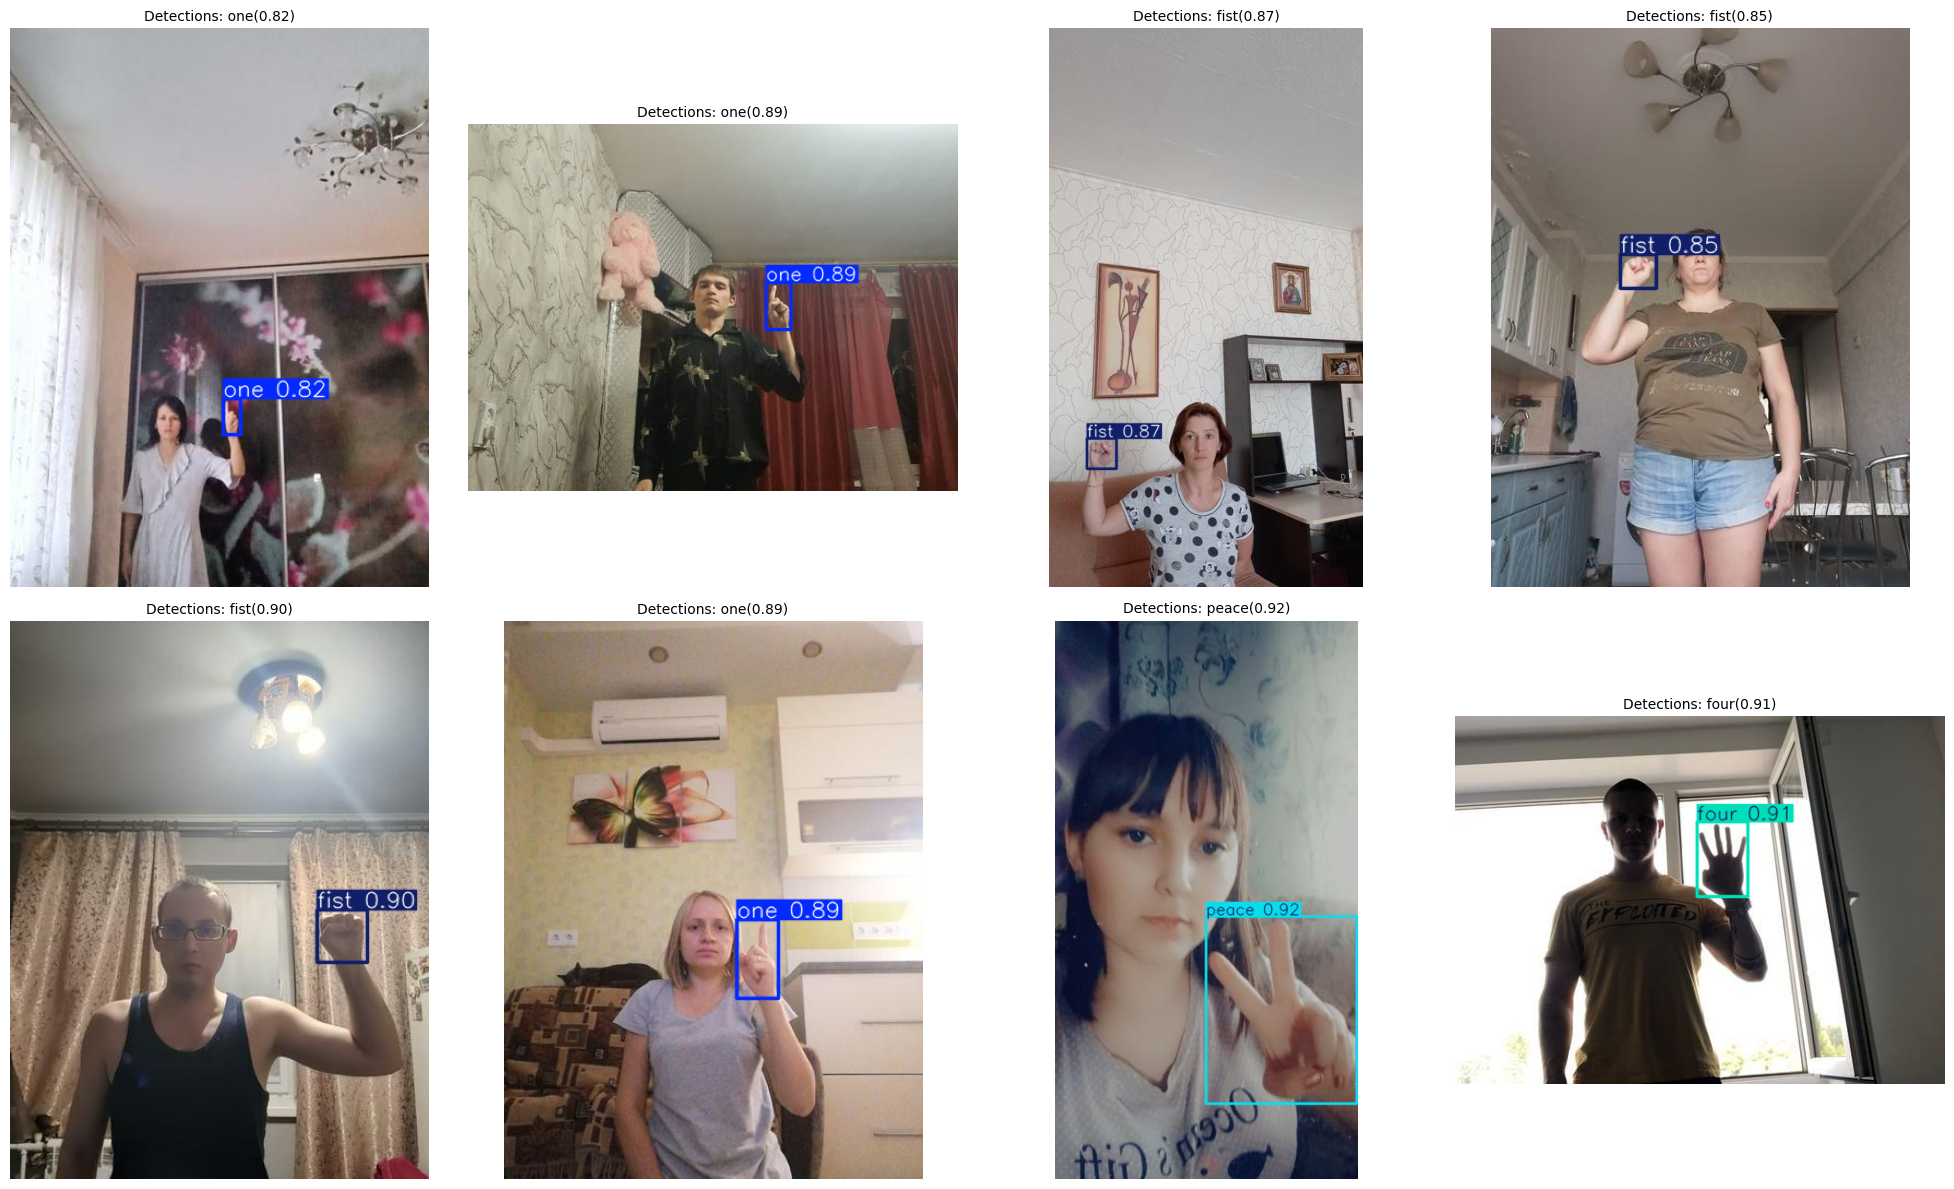

✓ Visualization complete


In [11]:
# Visualize predictions on sample images
print(f"\n{'='*70}")
print("VISUALIZING PREDICTIONS ON TEST SAMPLES")
print(f"{'='*70}")

def visualize_yolo_predictions(model, test_images_dir, n_show=8, conf_threshold=0.3):
    """Visualize YOLO predictions on sample images."""
    image_files = list(test_images_dir.glob('*'))[:n_show]
    
    if not image_files:
        print("No images found in test directory")
        return
    
    fig, axs = plt.subplots((n_show + 3) // 4, 4, figsize=(20, 12))
    axs = axs.flatten()
    
    for i, img_path in enumerate(image_files):
        results = model.predict(
            source=str(img_path),
            conf=conf_threshold,
            imgsz=TRAIN_IMG_SIZE,
            device=0 if torch.cuda.is_available() else 'cpu',
            verbose=False,
        )
        
        result = results[0]
        img_with_boxes = result.plot()
        axs[i].imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
        
        detections = result.boxes
        if len(detections) > 0:
            class_names = [TARGET_CLASSES[int(cls_id)] for cls_id in detections.cls]
            confidences = [f"{conf:.2f}" for conf in detections.conf]
            title = f"Detections: {', '.join([f'{cn}({cf})' for cn, cf in zip(class_names, confidences)])}"
        else:
            title = "No detections"
        
        axs[i].set_title(title, fontsize=10)
        axs[i].axis('off')
    
    for j in range(i + 1, len(axs)):
        axs[j].axis('off')
    
    plt.tight_layout()
    plt.show()

visualize_yolo_predictions(trained_model, test_images_dir, n_show=8, conf_threshold=0.3)
print("✓ Visualization complete")


SINGLE IMAGE INFERENCE

Inferring on: /kaggle/working/yolo_hagrid_dataset/yolo_splits/test/images/af67cd68-44f5-4640-a680-28fb659213b3.jpg

✓ Found 1 detection(s):
  1. one: confidence=0.82
     Box: [195.0, 339.6, 211.4, 372.4]


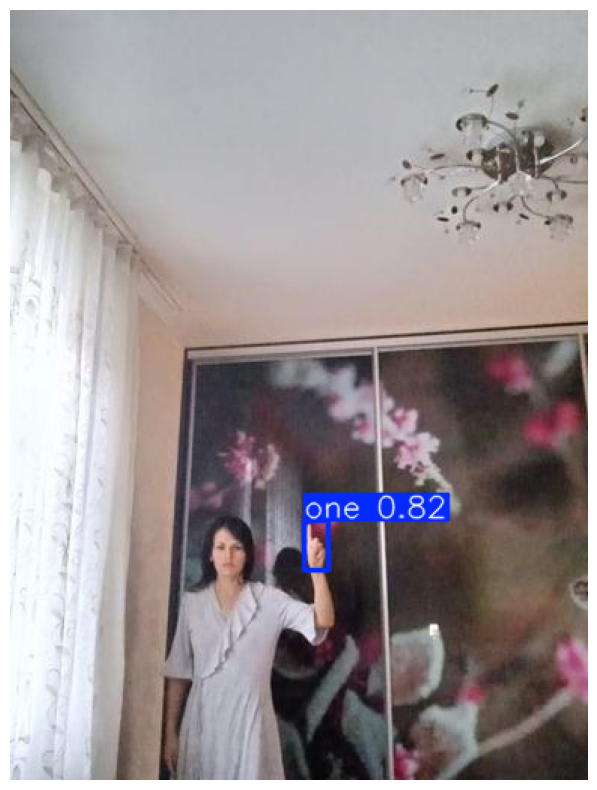

In [12]:
# Single image inference
print(f"\n{'='*70}")
print("SINGLE IMAGE INFERENCE")
print(f"{'='*70}")

def run_single_image_inference(model, image_path, conf_threshold=0.3):
    """Run inference on a single image and visualize."""
    print(f"\nInferring on: {image_path}")
    
    results = model.predict(
        source=str(image_path),
        conf=conf_threshold,
        imgsz=TRAIN_IMG_SIZE,
        device=0 if torch.cuda.is_available() else 'cpu',
        verbose=False,
    )
    
    result = results[0]
    img_with_boxes = result.plot()
    
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    
    detections = result.boxes
    if len(detections) > 0:
        print(f"\n✓ Found {len(detections)} detection(s):")
        for i, (box, cls_id, conf) in enumerate(zip(detections.xyxy, detections.cls, detections.conf)):
            class_name = TARGET_CLASSES[int(cls_id)]
            x1, y1, x2, y2 = box.cpu().numpy()
            print(f"  {i+1}. {class_name}: confidence={float(conf):.2f}")
            print(f"     Box: [{x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f}]")
    else:
        print("\n✗ No detections found")
    
    plt.tight_layout()
    plt.show()
    return result

sample_test_images = list((yolo_root / 'test' / 'images').glob('*'))
if sample_test_images:
    sample_image = sample_test_images[0]
    result = run_single_image_inference(trained_model, sample_image, conf_threshold=0.3)

In [13]:
# Export model to different formats
print(f"\n{'='*70}")
print("MODEL EXPORT AND DEPLOYMENT")
print(f"{'='*70}")

exported_paths = {}

# Export ONNX
try:
    print("  Exporting to ONNX...")
    onnx_path = trained_model.export(format='onnx', imgsz=TRAIN_IMG_SIZE)
    exported_paths['ONNX'] = onnx_path
    print(f"    ✓ ONNX: {onnx_path}")
except Exception as e:
    print(f"    ✗ ONNX export failed: {str(e)[:60]}")

# Export TensorFlow
try:
    print("  Exporting to TensorFlow...")
    tf_path = trained_model.export(format='pb', imgsz=TRAIN_IMG_SIZE)
    exported_paths['TensorFlow'] = tf_path
    print(f"    ✓ TensorFlow: {tf_path}")
except Exception as e:
    print(f"    ✗ TensorFlow export failed: {str(e)[:60]}")

print(f"\n✓ Model exports complete")
print(f"  Main model: {MODEL_SAVE_PATH}")
print(f"  Additional exports: {list(exported_paths.keys())}")


MODEL EXPORT AND DEPLOYMENT
  Exporting to ONNX...
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/models/yolo11n_hagrid_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 270ms
 Downloaded onnxruntime-gpu
Prepared 2 packages in 2.27s
Installed 2 packages in 15ms
 + onnxruntime-gpu==1.25.1
 + onnxslim==0.1.92

requirements: AutoUpdate success ✅ 3.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 5.4s, 

E0000 00:00:1778126059.349876      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778126059.475080      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778126060.579329      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778126060.579393      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778126060.579397      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778126060.579399      23 computation_placer.cc:177] computation placer already registered. Please check linka

requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx2tf>=1.26.3,<1.29.0'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 1.51s
 Downloaded ai-edge-litert
Prepared 5 packages in 222ms
Installed 5 packages in 18ms
 + ai-edge-litert==2.1.4
 + backports-strenum==1.3.1
 + onnx-graphsurgeon==0.6.1
 + onnx2tf==1.28.8
 + sng4onnx==2.0.1

requirements: AutoUpdate success ✅ 1.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


TensorFlow SavedModel: starting export with tensorflow 2.19.0...
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /kaggle/working/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 52.7files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...


I0000 00:00:1778126098.828613      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12533 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778126098.834000      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13755 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1778126102.528450      23 cuda_dnn.cc:529] Loaded cuDNN version 91002


Saved artifact at '/kaggle/working/models/yolo11n_hagrid_best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 9, 8400), dtype=tf.float32, name=None)
Captures:
  134535456019024: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  134535456017872: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  134535456018256: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  134535456019216: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  134535456023632: TensorSpec(shape=(3, 3, 16, 32), dtype=tf.float32, name=None)
  134535456023248: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  134535456022480: TensorSpec(shape=(1, 1, 32, 32), dtype=tf.float32, name=None)
  134535456023824: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  134535456024784: TensorSpec(shape=(4,), dtype=tf.int64, name=None)
  1

I0000 00:00:1778126110.450714      23 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1778126110.450900      23 single_machine.cc:374] Starting new session
I0000 00:00:1778126110.464131      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12533 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778126110.465559      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13755 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
W0000 00:00:1778126111.275674      23 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1778126111.275702      23 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1778126112.126663      23 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1778126112.126

TensorFlow SavedModel: export success ✅ 61.1s, saved as '/kaggle/working/models/yolo11n_hagrid_best_saved_model' (25.3 MB)

TensorFlow GraphDef: starting export with tensorflow 2.19.0...


I0000 00:00:1778126114.659542      23 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1778126114.659823      23 single_machine.cc:374] Starting new session
I0000 00:00:1778126114.673138      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12533 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778126114.674544      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13755 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


TensorFlow GraphDef: export success ✅ 1.3s, saved as '/kaggle/working/models/yolo11n_hagrid_best.pb' (10.1 MB)

Export complete (62.6s)
Results saved to /kaggle/working/models/yolo11n_hagrid_best.pb
Predict:         yolo predict task=detect model=/kaggle/working/models/yolo11n_hagrid_best.pb imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/models/yolo11n_hagrid_best.pb imgsz=640 data=/kaggle/working/yolo_hagrid_dataset/yolo_splits/data.yaml  
Visualize:       https://netron.app
    ✓ TensorFlow: /kaggle/working/models/yolo11n_hagrid_best.pb

✓ Model exports complete
  Main model: /kaggle/working/models/yolo11n_hagrid_best.pt
  Additional exports: ['ONNX', 'TensorFlow']


In [14]:
# Environment-specific save/download handling
print(f"\n{'='*70}")
print("MODEL SAVE/DOWNLOAD (Environment-Aware)")
print(f"{'='*70}")

print(f"Environment: {ENVIRONMENT}")
print(f"Model directory: {MODEL_DIR}")
print(f"Model file: {MODEL_SAVE_PATH}")
print(f"Model exists: {MODEL_SAVE_PATH.exists()}")

if MODEL_SAVE_PATH.exists():
    print(f"✓ Model saved successfully")
    file_size_mb = MODEL_SAVE_PATH.stat().st_size / (1024**2)
    print(f"  File size: {file_size_mb:.2f} MB")
    
    if ENVIRONMENT == 'colab':
        try:
            from google.colab import files
            print(f"\nPreparing to download '{MODEL_SAVE_PATH.name}'...")
            files.download(str(MODEL_SAVE_PATH))
            print(f"✓ Downloaded successfully")
        except ImportError:
            print("ERROR: google.colab not available")
    elif ENVIRONMENT == 'kaggle':
        print(f"\n✓ Model saved to Kaggle output")
        print("  Download from 'Output' tab in Kaggle notebook")
    else:
        print(f"\n✓ Model saved locally: {MODEL_SAVE_PATH}")
        print("  Ready for deployment")
else:
    print(f"⚠ Model file not found")

# Save metadata
metadata = {
    'model_type': 'Ultralytics YOLO11n',
    'model_name': model_name,
    'model_file': model_file,
    'classes': TARGET_CLASSES,
    'class_to_id': CLASS_TO_ID,
    'image_size': TRAIN_IMG_SIZE,
    'epochs_trained': TRAIN_EPOCHS,
    'batch_size': TRAIN_BATCH_SIZE,
    'metrics': metrics_summary,
    'training_date': pd.Timestamp.now().isoformat(),
    'environment': ENVIRONMENT,
}

metadata_path = MODEL_DIR / 'yolo11n_hagrid_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\n✓ Metadata saved to {metadata_path}")


MODEL SAVE/DOWNLOAD (Environment-Aware)
Environment: kaggle
Model directory: /kaggle/working/models
Model file: /kaggle/working/models/yolo11n_hagrid_best.pt
Model exists: True
✓ Model saved successfully
  File size: 5.20 MB

✓ Model saved to Kaggle output
  Download from 'Output' tab in Kaggle notebook

✓ Metadata saved to /kaggle/working/models/yolo11n_hagrid_metadata.json


In [15]:
# Latency and performance benchmarking
print(f"\n{'='*70}")
print("PERFORMANCE BENCHMARKING")
print(f"{'='*70}")

import time

def benchmark_model(model, test_images_dir, num_samples=50):
    """Benchmark model inference latency."""
    image_files = list(test_images_dir.glob('*'))[:num_samples]
    
    if not image_files:
        print("No test images found")
        return None
    
    latencies = []
    print(f"Benchmarking on {len(image_files)} images...")
    
    for img_path in tqdm(image_files, desc='Benchmark'):
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        
        t0 = time.perf_counter()
        results = model.predict(
            source=str(img_path),
            conf=0.3,
            imgsz=TRAIN_IMG_SIZE,
            device=0 if torch.cuda.is_available() else 'cpu',
            verbose=False,
        )
        
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        
        t1 = time.perf_counter()
        latencies.append((t1 - t0) * 1000)
    
    mean_latency = np.mean(latencies)
    std_latency = np.std(latencies)
    min_latency = np.min(latencies)
    max_latency = np.max(latencies)
    
    print(f"\n✓ Latency Statistics:")
    print(f"  Mean: {mean_latency:.2f} ms")
    print(f"  Std: {std_latency:.2f} ms")
    print(f"  Min: {min_latency:.2f} ms")
    print(f"  Max: {max_latency:.2f} ms")
    print(f"  FPS (mean): {1000/mean_latency:.1f}")
    
    return {
        'mean_ms': mean_latency,
        'std_ms': std_latency,
        'min_ms': min_latency,
        'max_ms': max_latency,
        'fps': 1000 / mean_latency,
    }

latency_stats = benchmark_model(trained_model, test_images_dir, num_samples=50)


PERFORMANCE BENCHMARKING
Benchmarking on 50 images...


Benchmark:   0%|          | 0/50 [00:00<?, ?it/s]


✓ Latency Statistics:
  Mean: 11.62 ms
  Std: 1.02 ms
  Min: 10.68 ms
  Max: 17.70 ms
  FPS (mean): 86.1


## Summary: YOLOv11n Performance

This variant provides:
- **Model**: YOLOv11 Nano (hardcoded, no fallback)
- **Epochs**: 80 (increased from 50 for better nano convergence)
- **Best-model selection**: Automatic based on validation mAP50
- **Training strategy**: Extended training with patience=20
- **Key advantage**: Fastest YOLO model with competitive mAP50

### Performance Comparison

| Metric | Value |
|--------|-------|
|mAP50|See metrics_summary above|
|Epochs|80|
|Model Size|Nano (~2.6 MB)|
|Inference Speed|See benchmark above|


## Tips for Using YOLOv11n Variant

### Why YOLOv11n (Nano)?
- **Speed**: Fastest YOLO model for real-time inference
- **Size**: Smallest weights (~2.6 MB), ideal for edge deployment
- **mAP50**: Surprisingly good for a nano model with proper training

### Why 80 Epochs?
- Default 50 epochs may be insufficient for nano to converge
- Extended training allows better weight optimization
- Early stopping (patience=20) prevents overfitting

### Best-Model Selection
- Ultralytics automatically saves best.pt during training
- Best model chosen based on validation fitness (mAP)
- Copied to MODEL_SAVE_PATH for easy access

### Compare with main_yolo26.ipynb
- main_yolo26: Auto-detection (tries YOLOv11n → YOLOv8n) with 50 epochs
- main_yolo11n: YOLOv11n hardcoded with 80 epochs
- This variant is optimized for speed; use if nano is your target

### Production Deployment
1. Export to ONNX for CPU inference
2. Use best.pt for edge devices (tiny size)
3. Benchmark latency on target hardware
4. Consider INT8 quantization for further speedup